# **Linaer and Multi-linear Regression**

In [1]:
# Simple Linear Regression using Gradient Descent (1 feature)
import random

# Sample data (x: feature, y: target)
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]  # perfect line: y = 2x

# Initialize parameters
w = random.random()
b = random.random()

# Hyperparameters
lr = 0.01
epochs = 1000
n = len(x)

# Training loop
for epoch in range(epochs):
    dw = 0
    db = 0
    for i in range(n):
        y_pred = w * x[i] + b
        error = y_pred - y[i]
        dw += error * x[i]
        db += error
    dw /= n
    db /= n

    # Update weights
    w -= lr * dw
    b -= lr * db

    if epoch % 100 == 0:
        loss = sum((w * x[i] + b - y[i])**2 for i in range(n)) / n
        print(f"Epoch {epoch}: w={w:.4f}, b={b:.4f}, Loss={loss:.4f}")

print(f"\nFinal Model: y = {w:.4f}x + {b:.4f}")


Epoch 0: w=0.2560, b=0.3636, Loss=29.7835
Epoch 100: w=1.8161, b=0.6639, Loss=0.0802
Epoch 200: w=1.8447, b=0.5606, Loss=0.0572
Epoch 300: w=1.8689, b=0.4733, Loss=0.0408
Epoch 400: w=1.8893, b=0.3996, Loss=0.0291
Epoch 500: w=1.9065, b=0.3374, Loss=0.0207
Epoch 600: w=1.9211, b=0.2849, Loss=0.0148
Epoch 700: w=1.9334, b=0.2406, Loss=0.0105
Epoch 800: w=1.9437, b=0.2031, Loss=0.0075
Epoch 900: w=1.9525, b=0.1715, Loss=0.0054

Final Model: y = 1.9598x + 0.1451


In [2]:
# Multiple Linear Regression using Gradient Descent (d features)
import random

# Sample data: 3 samples, 2 features
X = [
    [1, 2],
    [2, 3],
    [3, 4]
]
y = [6, 9, 12]  # underlying true model: y = 2x1 + 2x2

# Initialize weights and bias
d = len(X[0])  # number of features
w = [random.random() for _ in range(d)]
b = random.random()

# Hyperparameters
lr = 0.01
epochs = 1000
n = len(X)

# Training loop
for epoch in range(epochs):
    dw = [0] * d
    db = 0
    for i in range(n):
        y_pred = sum(w[j] * X[i][j] for j in range(d)) + b
        error = y_pred - y[i]
        for j in range(d):
            dw[j] += error * X[i][j]
        db += error
    for j in range(d):
        dw[j] /= n
        w[j] -= lr * dw[j]
    db /= n
    b -= lr * db

    if epoch % 100 == 0:
        loss = sum((sum(w[j] * X[i][j] for j in range(d)) + b - y[i])**2 for i in range(n)) / n
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

print(f"\nFinal weights: {w}")
print(f"Final bias: {b}")


Epoch 0: Loss = 19.2912
Epoch 100: Loss = 0.0691
Epoch 200: Loss = 0.0531
Epoch 300: Loss = 0.0408
Epoch 400: Loss = 0.0314
Epoch 500: Loss = 0.0241
Epoch 600: Loss = 0.0185
Epoch 700: Loss = 0.0142
Epoch 800: Loss = 0.0109
Epoch 900: Loss = 0.0084

Final weights: [1.3608788498644813, 1.7336820572182916]
Final bias: 1.054468041960039


# **Normal Equation**  
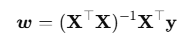

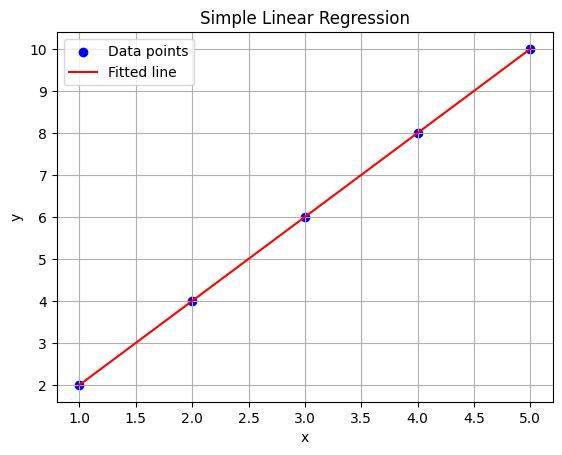

Final weights: [5.66213743e-15 2.00000000e+00]


In [3]:
                       #Feature – Line Plot
import numpy as np
import matplotlib.pyplot as plt

# Sample data (1 feature)
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 6, 8, 10])

# Add intercept term (bias)
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape: (n, 2)

# Normal Equation
w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Predict
y_pred = X_b @ w

# Plot
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label='Fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final weights: {w}")


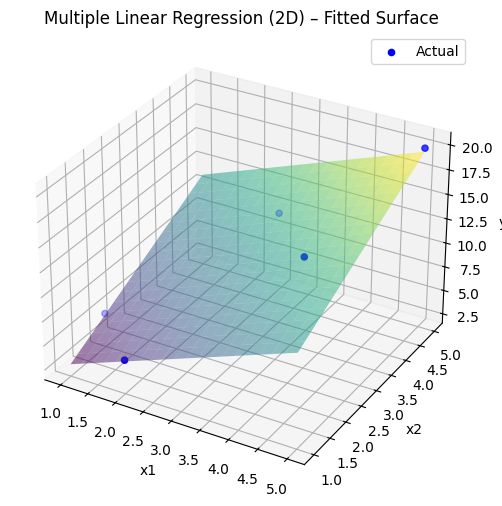

Final weights: [-1.46666667  2.11111111  2.11111111]


In [4]:
                          #Feature – 3D Surface Plot
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


# Sample data (2 features)
X = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 3],
    [5, 5]
])
y = np.array([5, 5, 13, 13, 20])

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # (n, d+1)

# Normal Equation
w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Predict
y_pred = X_b @ w

# Plot 3D surface
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Actual')

# Meshgrid for surface
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Y_grid = (w[0] + w[1] * X1_grid + w[2] * X2_grid)

# Surface plot
ax.plot_surface(X1_grid, X2_grid, Y_grid, alpha=0.5, cmap=cm.viridis)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Multiple Linear Regression (2D) – Fitted Surface')
plt.legend()
plt.show()

print(f"Final weights: {w}")


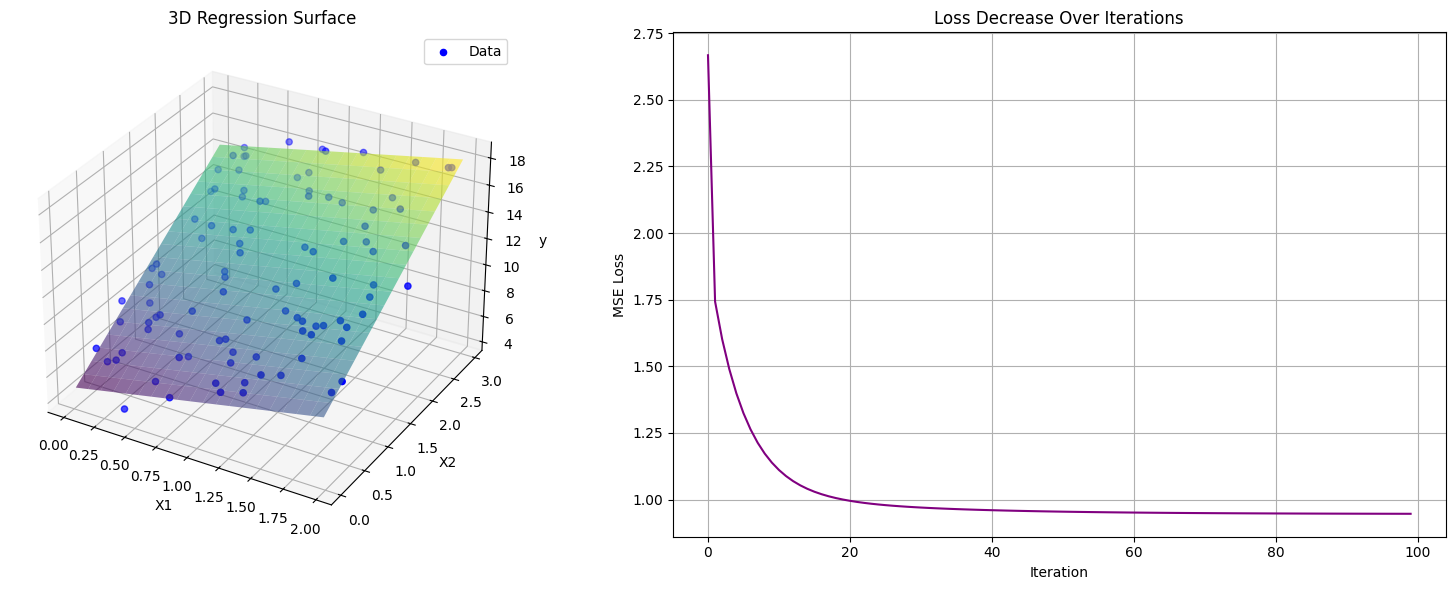

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic data
np.random.seed(42)
X1 = 2 * np.random.rand(100, 1)
X2 = 3 * np.random.rand(100, 1)
y = 5 + 2 * X1 + 3 * X2 + np.random.randn(100, 1)

# Combine features and add bias term
X = np.c_[X1, X2]
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape: (n_samples, 3)

# Gradient Descent parameters
n_iterations = 100
learning_rate = 0.1
m = len(y)
theta = np.random.randn(3, 1)  # weights: (bias, X1, X2)
loss_history = []

# Gradient Descent loop
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T @ (X_b @ theta - y)
    theta = theta - learning_rate * gradients
    loss = np.mean((X_b @ theta - y) ** 2)
    loss_history.append(loss)

# Prediction surface for 3D plot
x1_range = np.linspace(X1.min(), X1.max(), 20)
x2_range = np.linspace(X2.min(), X2.max(), 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Y_grid = theta[0] + theta[1] * X1_grid + theta[2] * X2_grid

# Plotting
fig = plt.figure(figsize=(16, 6))

# 3D Regression Surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1, X2, y, color='blue', label='Data')
ax1.plot_surface(X1_grid, X2_grid, Y_grid, cmap=cm.viridis, alpha=0.6)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('y')
ax1.set_title('3D Regression Surface')
ax1.legend()

# Loss vs Iterations
ax2 = fig.add_subplot(122)
ax2.plot(range(n_iterations), loss_history, color='purple')
ax2.set_title('Loss Decrease Over Iterations')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('MSE Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()
